# Multi-Model Comparison — 5-Class Multiclass (v7 Data)

Runs **8 models** on the same data and split as `diagnosis_model_multiclass_roberta_v7.ipynb`.

**Task**: Predict `multiclass_label` ∈ {adhd, anxiety, control, depression, suicidewatch}

| Tier | Models |
|------|--------|
| Classical ML (TF-IDF) | Logistic Regression, LinearSVC, Random Forest |
| Neural (GloVe-100d) | TextCNN, BiLSTM |
| Transformer | DistilBERT-base, MentalBERT-base, BERT-base |
| Reference (v7) | RoBERTa-base — Acc=0.9012, Macro-F1=0.8988 |

## Section 1 — Imports & Global Setup

In [53]:
import pandas as pd
import numpy as np
import re
import os
import time
import zipfile
import urllib.request
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Matplotlib for in-notebook visualizations ────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ── Device ──────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ── Global results accumulator ───────────────────────────────────────────────
all_results = {}

# Reference result from v7 RoBERTa (already trained)
all_results['RoBERTa-base (v7 ref)'] = {
    'type': 'Transformer',
    'accuracy': 0.9012,
    'macro_f1': 0.8988,
    'weighted_f1': 0.9002,
    'train_time_min': None,
}
print('Imports OK.')

Using device: cuda
Imports OK.


## Section 2 — Data Loading, Preprocessing & Splits

Identical to v7: shuffle with `random_state=42`, minimal preprocessing on `other_posts`,
filter to 5 classes, 80/10/10 stratified split with `random_state=42`.

In [54]:
def minimal_preprocess(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('Loading dataset...')
data = pd.read_csv('generated_augmented_suicidewatch_filtered_optimisticadded_data.csv')
print(f'Loaded: {data.shape}')

# ── Shuffle — same as v7 ─────────────────────────────────────────────────────
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

data['other_posts'] = data['other_posts'].apply(minimal_preprocess)
data = data[data['other_posts'].str.len() > 0].reset_index(drop=True)
print(f'After cleaning empty text: {len(data)} rows')

# Filter to the same 5 classes used in v7
PICKED_CLASSES = ['adhd', 'anxiety', 'control', 'depression', 'suicidewatch']
data = data[data['multiclass_label'].isin(PICKED_CLASSES)].reset_index(drop=True)
print(f'After class filter: {len(data)} rows')
print('\nClass distribution:')
print(data['multiclass_label'].value_counts())

Loading dataset...
Loaded: (68769, 33)
After cleaning empty text: 67987 rows
After class filter: 43801 rows

Class distribution:
multiclass_label
adhd            12560
anxiety         10078
control          9687
depression       9073
suicidewatch     2403
Name: count, dtype: int64


In [55]:
# ── Encode labels ────────────────────────────────────────────────────────────
le = LabelEncoder()
data['_y'] = le.fit_transform(data['multiclass_label'].astype(str))
class_names = list(le.classes_)
num_labels = len(class_names)
print(f'Classes ({num_labels}): {class_names}')

# ── 80/10/10 stratified split — same random_state=42 as v7 ──────────────────
train_df, temp_df = train_test_split(data, test_size=0.2, random_state=42, stratify=data['_y'])
val_df,   test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['_y'])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f'Split: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}')

# ── Class weights (shared by all models) ─────────────────────────────────────
cw = compute_class_weight('balanced', classes=np.arange(num_labels), y=train_df['_y'].values)
class_weights_tensor = torch.tensor(cw, dtype=torch.float)
print(f'Class weights: { {n: round(float(w), 3) for n, w in zip(class_names, cw)} }')

Classes (5): ['adhd', 'anxiety', 'control', 'depression', 'suicidewatch']
Split: train=35040, val=4380, test=4381
Class weights: {'adhd': 0.697, 'anxiety': 0.869, 'control': 0.904, 'depression': 0.966, 'suicidewatch': 3.646}


## Section 3 — Classical ML with TF-IDF

**Why TF-IDF?** Converts raw text into a sparse high-dimensional vector of term frequencies
(sublinear-scaled), weighted by inverse document frequency. Unigrams capture individual
discriminative words; bigrams capture short phrases (e.g. "panic attack", "feeling depressed").

**Why these 3 classifiers?**
- **Logistic Regression** — gold-standard text baseline; fast, interpretable, works well with high-dimensional sparse inputs.
- **LinearSVC** — finds the max-margin separating hyperplane; historically the strongest classical text classifier.
- **Random Forest** — non-linear ensemble; captures feature interactions that linear models miss.

In [28]:
print('Fitting TF-IDF (unigrams + bigrams, max_features=50000, sublinear_tf=True)...')
t0 = time.time()
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=50_000, sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(train_df['other_posts'])
X_val_tfidf   = tfidf.transform(val_df['other_posts'])
X_test_tfidf  = tfidf.transform(test_df['other_posts'])
print(f'Done in {time.time()-t0:.1f}s — train matrix: {X_train_tfidf.shape}')

# ── Classical model evaluation helper ─────────────────────────────────────────
def evaluate_classical(name, model_type, preds, y_test, train_time_sec):
    acc        = accuracy_score(y_test, preds)
    macro_f1   = f1_score(y_test, preds, average='macro',    zero_division=0)
    weighted_f1= f1_score(y_test, preds, average='weighted', zero_division=0)
    print(f'\n{"="*70}')
    print(f'TEST RESULTS — {name}')
    print(f'{"="*70}')
    print(f'Accuracy:    {acc:.4f}')
    print(f'Macro F1:    {macro_f1:.4f}')
    print(f'Weighted F1: {weighted_f1:.4f}')
    print(f'Train time:  {train_time_sec:.1f}s')
    print('\nClassification report:')
    print(classification_report(y_test, preds, target_names=class_names, zero_division=0))
    print('Confusion matrix (rows=true, cols=pred):')
    print(confusion_matrix(y_test, preds))
    all_results[name] = {
        'type': model_type,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'train_time_min': train_time_sec / 60,
    }

Fitting TF-IDF (unigrams + bigrams, max_features=50000, sublinear_tf=True)...
Done in 18.7s — train matrix: (35040, 50000)


In [29]:
# ── Logistic Regression ───────────────────────────────────────────────────────
# Note: multi_class='multinomial' is deprecated in sklearn >=1.5; solver='lbfgs'
# already defaults to multinomial for multiclass. Removed to silence the warning.
print('Training Logistic Regression...')
t0 = time.time()
lr_model = LogisticRegression(
    class_weight='balanced', max_iter=1000, C=1.0,
    solver='lbfgs', n_jobs=-1,
)
lr_model.fit(X_train_tfidf, train_df['_y'])
elapsed = time.time() - t0
preds = lr_model.predict(X_test_tfidf)
evaluate_classical('Logistic Regression (TF-IDF)', 'Classical ML', preds, test_df['_y'], elapsed)

Training Logistic Regression...

TEST RESULTS — Logistic Regression (TF-IDF)
Accuracy:    0.8496
Macro F1:    0.8477
Weighted F1: 0.8500
Train time:  15.8s

Classification report:
              precision    recall  f1-score   support

        adhd       0.89      0.89      0.89      1256
     anxiety       0.83      0.81      0.82      1008
     control       0.91      0.87      0.89       969
  depression       0.76      0.81      0.78       908
suicidewatch       0.82      0.89      0.85       240

    accuracy                           0.85      4381
   macro avg       0.84      0.85      0.85      4381
weighted avg       0.85      0.85      0.85      4381

Confusion matrix (rows=true, cols=pred):
[[1118   59   13   62    4]
 [  63  815   36   87    7]
 [  19   36  845   58   11]
 [  58   65   30  731   24]
 [   2    2    3   20  213]]


In [30]:
# ── LinearSVC ─────────────────────────────────────────────────────────────────
print('Training LinearSVC...')
t0 = time.time()
svc_model = LinearSVC(class_weight='balanced', max_iter=2000, C=1.0)
svc_model.fit(X_train_tfidf, train_df['_y'])
elapsed = time.time() - t0
preds = svc_model.predict(X_test_tfidf)
evaluate_classical('LinearSVC (TF-IDF)', 'Classical ML', preds, test_df['_y'], elapsed)

Training LinearSVC...

TEST RESULTS — LinearSVC (TF-IDF)
Accuracy:    0.9080
Macro F1:    0.9038
Weighted F1: 0.9080
Train time:  4.1s

Classification report:
              precision    recall  f1-score   support

        adhd       0.92      0.94      0.93      1256
     anxiety       0.89      0.90      0.89      1008
     control       0.95      0.92      0.94       969
  depression       0.87      0.87      0.87       908
suicidewatch       0.91      0.87      0.89       240

    accuracy                           0.91      4381
   macro avg       0.91      0.90      0.90      4381
weighted avg       0.91      0.91      0.91      4381

Confusion matrix (rows=true, cols=pred):
[[1185   34    6   31    0]
 [  42  903   16   44    3]
 [  12   31  890   29    7]
 [  49   44   14  791   10]
 [   4    3    8   16  209]]


In [31]:
# ── Random Forest ─────────────────────────────────────────────────────────────
print('Training Random Forest (200 trees)...')
t0 = time.time()
rf_model = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42
)
rf_model.fit(X_train_tfidf, train_df['_y'])
elapsed = time.time() - t0
preds = rf_model.predict(X_test_tfidf)
evaluate_classical('Random Forest (TF-IDF)', 'Classical ML', preds, test_df['_y'], elapsed)

Training Random Forest (200 trees)...

TEST RESULTS — Random Forest (TF-IDF)
Accuracy:    0.8377
Macro F1:    0.8284
Weighted F1: 0.8369
Train time:  165.3s

Classification report:
              precision    recall  f1-score   support

        adhd       0.83      0.93      0.87      1256
     anxiety       0.84      0.81      0.83      1008
     control       0.89      0.85      0.87       969
  depression       0.77      0.77      0.77       908
suicidewatch       0.95      0.69      0.80       240

    accuracy                           0.84      4381
   macro avg       0.86      0.81      0.83      4381
weighted avg       0.84      0.84      0.84      4381

Confusion matrix (rows=true, cols=pred):
[[1165   37   11   43    0]
 [ 104  815   41   47    1]
 [  32   37  825   73    2]
 [ 100   71   32  699    6]
 [   9    7   13   45  166]]


## Section 4 — TextCNN (Kim, 2014) with GloVe-100d

**Why TextCNN?** Uses parallel 1D convolutions with different filter sizes (3, 4, 5 tokens) to
capture local n-gram patterns — e.g. "I was diagnosed with", "feeling hopeless again".

**Why GloVe?** Provides semantically rich word initializations (trained on 6B tokens).
Far better than random initializations on a dataset of this size.

> **GloVe is downloaded automatically** (~862 MB zip) if not already present.

In [32]:
GLOVE_PATH     = 'glove.6B.100d.txt'
GLOVE_ZIP_URL  = 'https://nlp.stanford.edu/data/glove.6B.zip'
GLOVE_ZIP_PATH = 'glove.6B.zip'
EMBED_DIM      = 100
MAX_LEN_NEURAL = 256
MAX_VOCAB      = 50_000
MIN_FREQ       = 2
NEURAL_BATCH   = 64
NEURAL_EPOCHS  = 10
NEURAL_LR      = 1e-3

# ── Auto-download GloVe if not present ───────────────────────────────────────
if not os.path.exists(GLOVE_PATH):
    if not os.path.exists(GLOVE_ZIP_PATH):
        print(f'GloVe not found. Downloading from Stanford ({GLOVE_ZIP_URL})...')
        print('This is ~862 MB — may take several minutes on a slow connection.')
        def _progress(block_num, block_size, total_size):
            pct = min(block_num * block_size / total_size * 100, 100)
            if block_num % 500 == 0:
                print(f'  {pct:.1f}% downloaded...', end='\r')
        urllib.request.urlretrieve(GLOVE_ZIP_URL, GLOVE_ZIP_PATH, reporthook=_progress)
        print(f'\nDownload complete: {GLOVE_ZIP_PATH}')
    else:
        print(f'Found existing zip: {GLOVE_ZIP_PATH}')

    print(f'Extracting {GLOVE_PATH} from zip...')
    with zipfile.ZipFile(GLOVE_ZIP_PATH, 'r') as z:
        z.extract('glove.6B.100d.txt', '.')
    print(f'Extracted: {GLOVE_PATH}')
else:
    print(f'Found: {GLOVE_PATH}')

# ── Build vocabulary from training data ───────────────────────────────────────
print('Building vocabulary from training set...')
counter = Counter()
for text in train_df['other_posts']:
    counter.update(text.split())
vocab_words = ['<PAD>', '<UNK>'] + [
    w for w, c in counter.most_common(MAX_VOCAB) if c >= MIN_FREQ
]
word2idx = {w: i for i, w in enumerate(vocab_words)}
vocab_size = len(vocab_words)
print(f'Vocabulary size: {vocab_size:,}')

# ── Load GloVe & build embedding matrix ──────────────────────────────────────
print('Loading GloVe vectors...')
t0 = time.time()
glove_vecs = {}
with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.rstrip().split(' ')
        glove_vecs[parts[0]] = np.array(parts[1:], dtype=np.float32)
print(f'Loaded {len(glove_vecs):,} vectors in {time.time()-t0:.1f}s')

embed_matrix = np.random.normal(0, 0.01, (vocab_size, EMBED_DIM)).astype(np.float32)
embed_matrix[0] = 0.0   # PAD = zeros
hits = 0
for i, word in enumerate(vocab_words):
    if word in glove_vecs:
        embed_matrix[i] = glove_vecs[word]
        hits += 1
print(f'GloVe coverage: {hits:,}/{vocab_size:,} ({100*hits/vocab_size:.1f}%)')
pretrained_embeddings = torch.tensor(embed_matrix)

# ── Tokenize all splits for neural models ────────────────────────────────────
def texts_to_sequences(texts, word2idx, max_len):
    seqs = []
    for text in texts:
        tokens = text.split()[:max_len]
        seq = [word2idx.get(t, 1) for t in tokens]   # 1 = <UNK>
        seq += [0] * (max_len - len(seq))             # 0 = <PAD>
        seqs.append(seq)
    return torch.tensor(seqs, dtype=torch.long)

print('Tokenizing all splits for neural models...')
X_train_neu = texts_to_sequences(train_df['other_posts'].tolist(), word2idx, MAX_LEN_NEURAL)
X_val_neu   = texts_to_sequences(val_df['other_posts'].tolist(),   word2idx, MAX_LEN_NEURAL)
X_test_neu  = texts_to_sequences(test_df['other_posts'].tolist(),  word2idx, MAX_LEN_NEURAL)
y_train_neu = torch.tensor(train_df['_y'].values, dtype=torch.long)
y_val_neu   = torch.tensor(val_df['_y'].values,   dtype=torch.long)
y_test_neu  = torch.tensor(test_df['_y'].values,  dtype=torch.long)
print('Done.')

Found: glove.6B.100d.txt
Building vocabulary from training set...
Vocabulary size: 50,002
Loading GloVe vectors...
Loaded 400,000 vectors in 11.8s
GloVe coverage: 19,225/50,002 (38.4%)
Tokenizing all splits for neural models...
Done.


In [33]:
# ── TextCNN model (Kim 2014) ──────────────────────────────────────────────────
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes,
                 num_filters=128, filter_sizes=(3, 4, 5),
                 dropout=0.5, pretrained_embeddings=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight = nn.Parameter(pretrained_embeddings.clone())
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x)         # (B, L, D)
        emb = emb.transpose(1, 2)       # (B, D, L)
        pooled = []
        for conv in self.convs:
            c = F.relu(conv(emb))
            p = F.max_pool1d(c, c.size(2)).squeeze(2)
            pooled.append(p)
        cat = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(cat))


# ── BiLSTM model ─────────────────────────────────────────────────────────────
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, pretrained_embeddings=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_embeddings is not None:
            self.embedding.weight = nn.Parameter(pretrained_embeddings.clone())
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.lstm(emb)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))


# ── Shared neural training / eval loop ──────────────────────────────────────
def train_and_eval_neural(model, X_train, y_train, X_val, y_val, X_test, y_test,
                           class_weights, num_epochs, batch_size, lr, device,
                           model_save_path, model_name, model_type):
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=batch_size)
    test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=batch_size)

    model = model.to(device)
    loss_fn   = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_f1 = 0.0
    t_start = time.time()
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for X_b, y_b in tqdm(train_loader, desc=f'[{model_name}] Epoch {epoch+1}/{num_epochs}'):
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(X_b)
            loss   = loss_fn(logits, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                p = model(X_b.to(device)).argmax(dim=1).cpu().numpy()
                val_preds.extend(p)
                val_true.extend(y_b.numpy())
        val_f1  = f1_score(val_true, val_preds, average='macro', zero_division=0)
        val_acc = accuracy_score(val_true, val_preds)
        print(f'Epoch {epoch+1}: loss={total_loss/len(train_loader):.4f}  '
              f'val_acc={val_acc:.4f}  val_macro_f1={val_f1:.4f}')
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), model_save_path)
            print(f'  -> saved {model_save_path}')

    train_time_min = (time.time() - t_start) / 60

    model.load_state_dict(torch.load(model_save_path, map_location=device))
    model.eval()
    test_preds, test_true = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            p = model(X_b.to(device)).argmax(dim=1).cpu().numpy()
            test_preds.extend(p)
            test_true.extend(y_b.numpy())

    acc         = accuracy_score(test_true, test_preds)
    macro_f1    = f1_score(test_true, test_preds, average='macro',    zero_division=0)
    weighted_f1 = f1_score(test_true, test_preds, average='weighted', zero_division=0)
    print(f'\n{"="*70}')
    print(f'TEST RESULTS — {model_name}')
    print(f'{"="*70}')
    print(f'Accuracy:    {acc:.4f}')
    print(f'Macro F1:    {macro_f1:.4f}')
    print(f'Weighted F1: {weighted_f1:.4f}')
    print(f'Train time:  {train_time_min:.1f} min')
    print('\nClassification report:')
    print(classification_report(test_true, test_preds, target_names=class_names, zero_division=0))
    print('Confusion matrix (rows=true, cols=pred):')
    print(confusion_matrix(test_true, test_preds))
    all_results[model_name] = {
        'type': model_type,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'train_time_min': train_time_min,
    }

print('Model classes and training helper defined.')

Model classes and training helper defined.


In [34]:
# ── Train TextCNN ─────────────────────────────────────────────────────────────
textcnn = TextCNN(
    vocab_size=vocab_size, embed_dim=EMBED_DIM, num_classes=num_labels,
    num_filters=128, filter_sizes=(3, 4, 5), dropout=0.5,
    pretrained_embeddings=pretrained_embeddings,
)
print(f'TextCNN parameters: {sum(p.numel() for p in textcnn.parameters()):,}')

train_and_eval_neural(
    model=textcnn,
    X_train=X_train_neu, y_train=y_train_neu,
    X_val=X_val_neu,     y_val=y_val_neu,
    X_test=X_test_neu,   y_test=y_test_neu,
    class_weights=class_weights_tensor,
    num_epochs=NEURAL_EPOCHS, batch_size=NEURAL_BATCH, lr=NEURAL_LR,
    device=device,
    model_save_path='best_textcnn_multiclass_v1.pt',
    model_name='TextCNN (GloVe-100d)', model_type='Neural',
)

TextCNN parameters: 5,156,109


[TextCNN (GloVe-100d)] Epoch 1/10: 100%|██████████| 548/548 [00:05<00:00, 95.08it/s] 


Epoch 1: loss=1.0523  val_acc=0.7084  val_macro_f1=0.6877
  -> saved best_textcnn_multiclass_v1.pt


[TextCNN (GloVe-100d)] Epoch 2/10: 100%|██████████| 548/548 [00:05<00:00, 103.69it/s]


Epoch 2: loss=0.6737  val_acc=0.7838  val_macro_f1=0.7785
  -> saved best_textcnn_multiclass_v1.pt


...

Epoch 8: loss=0.0842  val_acc=0.8884  val_macro_f1=0.8811
  -> saved best_textcnn_multiclass_v1.pt


[TextCNN (GloVe-100d)] Epoch 9/10: 100%|██████████| 548/548 [00:05<00:00, 105.71it/s]


Epoch 9: loss=0.0740  val_acc=0.8838  val_macro_f1=0.8764


[TextCNN (GloVe-100d)] Epoch 10/10: 100%|██████████| 548/548 [00:05<00:00, 104.20it/s]


Epoch 10: loss=0.0685  val_acc=0.8831  val_macro_f1=0.8752

TEST RESULTS — TextCNN (GloVe-100d)
Accuracy:    0.8959
Macro F1:    0.8860
Weighted F1: 0.8959
Train time:  0.9 min

Classification report:
              precision    recall  f1-score   support

        adhd       0.93      0.92      0.93      1256
     anxiety       0.89      0.87      0.88      1008
     control       0.92      0.93      0.92       969
  depression       0.84      0.87      0.85       908
suicidewatch       0.88      0.82      0.84       240

    accuracy                           0.90      4381
   macro avg       0.89      0.88      0.89      4381
weighted avg       0.90      0.90      0.90      4381

Confusion matrix (rows=true, cols=pred):
[[1159   42   13   41    1]
 [  43  880   26   54    5]
 [  12   14  901   32   10]
 [  29   49   29  789   12]
 [   3    2   13   26  196]]


## Section 5 — BiLSTM with GloVe-100d

**Why BiLSTM?** Reads the post left-to-right and right-to-left simultaneously, capturing
sequential and long-range dependencies — negation, co-references, and narrative structure.
Mean-pooling over all hidden states gives a fixed-size representation.

In [35]:
# ── Train BiLSTM ──────────────────────────────────────────────────────────────
bilstm = BiLSTMClassifier(
    vocab_size=vocab_size, embed_dim=EMBED_DIM, hidden_dim=256,
    num_classes=num_labels, num_layers=2, dropout=0.3,
    pretrained_embeddings=pretrained_embeddings,
)
print(f'BiLSTM parameters: {sum(p.numel() for p in bilstm.parameters()):,}')

train_and_eval_neural(
    model=bilstm,
    X_train=X_train_neu, y_train=y_train_neu,
    X_val=X_val_neu,     y_val=y_val_neu,
    X_test=X_test_neu,   y_test=y_test_neu,
    class_weights=class_weights_tensor,
    num_epochs=NEURAL_EPOCHS, batch_size=NEURAL_BATCH, lr=NEURAL_LR,
    device=device,
    model_save_path='best_bilstm_multiclass_v1.pt',
    model_name='BiLSTM (GloVe-100d)', model_type='Neural',
)

BiLSTM parameters: 7,312,909


[BiLSTM (GloVe-100d)] Epoch 1/10: 100%|██████████| 548/548 [00:52<00:00, 10.40it/s]


Epoch 1: loss=1.2431  val_acc=0.5829  val_macro_f1=0.5609
  -> saved best_bilstm_multiclass_v1.pt


[BiLSTM (GloVe-100d)] Epoch 2/10: 100%|██████████| 548/548 [00:51<00:00, 10.61it/s]


Epoch 2: loss=0.7539  val_acc=0.7361  val_macro_f1=0.7406
  -> saved best_bilstm_multiclass_v1.pt


...

Epoch 8: loss=0.1162  val_acc=0.8797  val_macro_f1=0.8673
  -> saved best_bilstm_multiclass_v1.pt


[BiLSTM (GloVe-100d)] Epoch 9/10: 100%|██████████| 548/548 [00:52<00:00, 10.53it/s]


Epoch 9: loss=0.0992  val_acc=0.8795  val_macro_f1=0.8677
  -> saved best_bilstm_multiclass_v1.pt


[BiLSTM (GloVe-100d)] Epoch 10/10: 100%|██████████| 548/548 [00:51<00:00, 10.54it/s]


Epoch 10: loss=0.0828  val_acc=0.8906  val_macro_f1=0.8782
  -> saved best_bilstm_multiclass_v1.pt

TEST RESULTS — BiLSTM (GloVe-100d)
Accuracy:    0.8900
Macro F1:    0.8769
Weighted F1: 0.8907
Train time:  9.0 min

Classification report:
              precision    recall  f1-score   support

        adhd       0.93      0.92      0.93      1256
     anxiety       0.87      0.87      0.87      1008
     control       0.96      0.89      0.92       969
  depression       0.81      0.88      0.85       908
suicidewatch       0.80      0.83      0.82       240

    accuracy                           0.89      4381
   macro avg       0.88      0.88      0.88      4381
weighted avg       0.89      0.89      0.89      4381

Confusion matrix (rows=true, cols=pred):
[[1160   44    3   48    1]
 [  44  877    8   73    6]
 [  13   35  863   38   20]
 [  27   41   18  799   23]
 [   1    6    9   24  200]]


## Section 6 — Transformer Models

All transformer models use the **same hyperparameters as v7 RoBERTa**:
- `MAX_LENGTH=256`, `BATCH_SIZE=16`, `NUM_EPOCHS=5`, `LR=2e-5`
- Class-weighted CrossEntropyLoss, Linear LR scheduler
- Best checkpoint selected on validation macro-F1

**DistilBERT** — 66M params, 40% smaller, 60% faster than BERT. Tests efficiency vs. quality.  
**MentalBERT** — Pre-trained on mental health Reddit posts. Domain-aligned for this task.  
**BERT-base** — Original reference encoder. Isolates RoBERTa's improvements (no NSP, dynamic masking).

In [36]:
# ── Shared transformer config (identical to v7) ──────────────────────────────
T_MAX_LENGTH = 256
T_BATCH_SIZE = 16
T_NUM_EPOCHS = 5
T_LR         = 2e-5


class TextClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item


def t_train_epoch(model, loader, optimizer, scheduler, device, loss_fn):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc='Training'):
        batch  = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop('labels')
        out    = model(**batch)
        loss   = loss_fn(out.logits, labels)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def t_evaluate(model, loader, device, loss_fn):
    model.eval()
    total_loss, preds, trues = 0, [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating'):
            batch  = {k: v.to(device) for k, v in batch.items()}
            labels = batch.pop('labels')
            out    = model(**batch)
            loss   = loss_fn(out.logits, labels)
            total_loss += loss.item()
            preds.extend(out.logits.argmax(dim=1).cpu().numpy())
            trues.extend(labels.cpu().numpy())
    return total_loss / len(loader), accuracy_score(trues, preds), preds, trues


def run_transformer_experiment(hf_model_name, display_name, model_save_path, fallbacks=None):
    print('\n' + '='*70)
    print(f'EXPERIMENT: {display_name}  ({hf_model_name})')
    print('='*70)

    print('Loading tokenizer...')
    tokenizer = None
    used_model_name = hf_model_name
    try:
        tokenizer = AutoTokenizer.from_pretrained(hf_model_name)
    except Exception as e:
        print(f"Warning: Failed to load tokenizer for '{hf_model_name}'. Error: {e}")
        if fallbacks:
            for fb in fallbacks:
                try:
                    print(f"Trying to load fallback tokenizer from local cache: {fb}...")
                    tokenizer = AutoTokenizer.from_pretrained(fb, local_files_only=True)
                    print(f"Successfully loaded fallback tokenizer: {fb}")
                    used_model_name = fb
                    break
                except Exception as fb_err:
                    print(f"Failed to load fallback tokenizer '{fb}': {fb_err}")
        if tokenizer is None:
            raise e

    def tok(texts):
        return tokenizer(
            texts.tolist(), max_length=T_MAX_LENGTH,
            padding='max_length', truncation=True, return_tensors='pt',
        )

    print('Tokenizing...')
    train_enc = tok(train_df['other_posts'])
    val_enc   = tok(val_df['other_posts'])
    test_enc  = tok(test_df['other_posts'])

    train_loader = DataLoader(TextClassificationDataset(train_enc, train_df['_y'].values),
                              batch_size=T_BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(TextClassificationDataset(val_enc,   val_df['_y'].values),
                              batch_size=T_BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(TextClassificationDataset(test_enc,  test_df['_y'].values),
                              batch_size=T_BATCH_SIZE, shuffle=False)

    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    print('Loading model...')
    model = None
    try:
        model = AutoModelForSequenceClassification.from_pretrained(
            used_model_name, num_labels=num_labels,
            id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True,
            local_files_only=(used_model_name != hf_model_name)
        ).to(device)
    except Exception as e:
        print(f"Warning: Failed to load model '{used_model_name}'. Error: {e}")
        if fallbacks and used_model_name == hf_model_name:
            for fb in fallbacks:
                try:
                    print(f"Trying to load fallback model from local cache: {fb}...")
                    model = AutoModelForSequenceClassification.from_pretrained(
                        fb, num_labels=num_labels,
                        id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True,
                        local_files_only=True
                    ).to(device)
                    print(f"Successfully loaded fallback model: {fb}")
                    break
                except Exception as fb_err:
                    print(f"Failed to load fallback model '{fb}': {fb_err}")
        if model is None:
            raise e

    loss_fn     = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
    optimizer   = AdamW(model.parameters(), lr=T_LR)
    total_steps = len(train_loader) * T_NUM_EPOCHS
    scheduler   = torch.optim.lr_scheduler.LinearLR(optimizer, total_iters=total_steps)

    best_val_f1 = 0.0
    t_start = time.time()
    for epoch in range(T_NUM_EPOCHS):
        print(f'\n--- Epoch {epoch+1}/{T_NUM_EPOCHS} ---')
        train_loss = t_train_epoch(model, train_loader, optimizer, scheduler, device, loss_fn)
        print(f'Train loss: {train_loss:.4f}')
        val_loss, val_acc, val_preds, val_true = t_evaluate(model, val_loader, device, loss_fn)
        val_f1 = f1_score(val_true, val_preds, average='macro', zero_division=0)
        print(f'Val loss: {val_loss:.4f}  acc: {val_acc:.4f}  macro-F1: {val_f1:.4f}')
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), model_save_path)
            print(f'  -> saved {model_save_path}')

    train_time_min = (time.time() - t_start) / 60

    model.load_state_dict(torch.load(model_save_path, map_location=device))
    _, test_acc, test_preds, test_true = t_evaluate(model, test_loader, device, loss_fn)
    macro_f1    = f1_score(test_true, test_preds, average='macro',    zero_division=0)
    weighted_f1 = f1_score(test_true, test_preds, average='weighted', zero_division=0)

    print('\n' + '='*70)
    print(f'TEST RESULTS — {display_name}')
    print('='*70)
    print(f'Accuracy:    {test_acc:.4f}')
    print(f'Macro F1:    {macro_f1:.4f}')
    print(f'Weighted F1: {weighted_f1:.4f}')
    print(f'Train time:  {train_time_min:.1f} min')
    print('\nClassification report:')
    print(classification_report(test_true, test_preds, target_names=class_names, zero_division=0))
    print('Confusion matrix (rows=true, cols=pred):')
    print(confusion_matrix(test_true, test_preds))

    all_results[display_name] = {
        'type': 'Transformer',
        'accuracy': test_acc, 'macro_f1': macro_f1,
        'weighted_f1': weighted_f1, 'train_time_min': train_time_min,
    }

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('Transformer utilities defined.')

Transformer utilities defined.


In [37]:
# ── Section 6a: DistilBERT-base ──────────────────────────────────────────────
run_transformer_experiment(
    hf_model_name='distilbert-base-uncased',
    display_name='DistilBERT-base',
    model_save_path='best_distilbert_multiclass_v1.pt',
)


EXPERIMENT: DistilBERT-base  (distilbert-base-uncased)
Loading tokenizer...
Tokenizing...
Loading model...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Epoch 1/5 ---


Training: 100%|██████████| 2190/2190 [08:07<00:00,  4.49it/s]


Train loss: 0.8125


...

Train loss: 0.1886


Evaluating: 100%|██████████| 274/274 [00:16<00:00, 16.55it/s]


Val loss: 0.4427  acc: 0.9005  macro-F1: 0.9022
  -> saved best_distilbert_multiclass_v1.pt


Evaluating: 100%|██████████| 274/274 [00:16<00:00, 16.53it/s]



TEST RESULTS — DistilBERT-base
Accuracy:    0.8939
Macro F1:    0.8908
Weighted F1: 0.8941
Train time:  42.0 min

Classification report:
              precision    recall  f1-score   support

        adhd       0.94      0.92      0.93      1256
     anxiety       0.82      0.92      0.87      1008
     control       0.95      0.92      0.94       969
  depression       0.87      0.81      0.84       908
suicidewatch       0.92      0.86      0.89       240

    accuracy                           0.89      4381
   macro avg       0.90      0.89      0.89      4381
weighted avg       0.90      0.89      0.89      4381

Confusion matrix (rows=true, cols=pred):
[[1152   64   11   29    0]
 [  34  930    7   34    3]
 [   9   38  893   26    3]
 [  35  103   23  735   12]
 [   2    2    7   23  206]]


In [38]:
# ── Section 6b: MentalBERT-base ───────────────────────────────────────────────
run_transformer_experiment(
    hf_model_name='mental/mental-bert-base-uncased',
    display_name='MentalBERT-base',
    model_save_path='best_mentalbert_multiclass_v1.pt',
    fallbacks=['slimshady07/Mental_BERT', 'Sharath45/MENTALBERT_MULTILABEL_CLASSIFICATION'],
)


EXPERIMENT: MentalBERT-base  (mental/mental-bert-base-uncased)
Loading tokenizer...
Make sure to have access to it at https://huggingface.co/mental/mental-bert-base-uncased.
403 Client Error. (Request ID: Root=1-6a3c5f24-26dd0a4709b7f89b52a944c3;72f4d5ac-c76a-41be-92d9-73972619b267)

Cannot access gated repo for url https://huggingface.co/mental/mental-bert-base-uncased/resolve/main/config.json.
Access to model mental/mental-bert-base-uncased is restricted and you are not in the authorized list. Visit https://huggingface.co/mental/mental-bert-base-uncased to ask for access.
Trying to load fallback tokenizer from local cache: slimshady07/Mental_BERT...
Successfully loaded fallback tokenizer: slimshady07/Mental_BERT
Tokenizing...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at slimshady07/Mental_BERT and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loading model...

--- Epoch 1/5 ---


Training: 100%|██████████| 2190/2190 [15:41<00:00,  2.33it/s]


Train loss: 0.7264


...

Train loss: 0.1509


Evaluating: 100%|██████████| 274/274 [00:32<00:00,  8.43it/s]


Val loss: 0.4199  acc: 0.9105  macro-F1: 0.9078
  -> saved best_mentalbert_multiclass_v1.pt


Evaluating: 100%|██████████| 274/274 [00:32<00:00,  8.43it/s]



TEST RESULTS — MentalBERT-base
Accuracy:    0.9103
Macro F1:    0.9039
Weighted F1: 0.9108
Train time:  81.2 min

Classification report:
              precision    recall  f1-score   support

        adhd       0.93      0.94      0.93      1256
     anxiety       0.90      0.89      0.89      1008
     control       0.98      0.93      0.95       969
  depression       0.84      0.88      0.86       908
suicidewatch       0.85      0.91      0.88       240

    accuracy                           0.91      4381
   macro avg       0.90      0.91      0.90      4381
weighted avg       0.91      0.91      0.91      4381

Confusion matrix (rows=true, cols=pred):
[[1175   39    3   39    0]
 [  42  899    5   57    5]
 [   5   22  897   38    7]
 [  36   39    7  798   28]
 [   0    3    3   15  219]]


In [39]:
# ── Section 6c: BERT-base ────────────────────────────────────────────────────
run_transformer_experiment(
    hf_model_name='bert-base-uncased',
    display_name='BERT-base',
    model_save_path='best_bert_multiclass_v1.pt',
)


EXPERIMENT: BERT-base  (bert-base-uncased)
Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Train loss: 0.1570


Evaluating: 100%|██████████| 274/274 [00:32<00:00,  8.42it/s]


Val loss: 0.4547  acc: 0.9080  macro-F1: 0.9062
  -> saved best_bert_multiclass_v1.pt


Evaluating: 100%|██████████| 274/274 [00:32<00:00,  8.41it/s]



TEST RESULTS — BERT-base
Accuracy:    0.8998
Macro F1:    0.8954
Weighted F1: 0.9007
Train time:  81.2 min

Classification report:
              precision    recall  f1-score   support

        adhd       0.94      0.91      0.93      1256
     anxiety       0.90      0.85      0.88      1008
     control       0.95      0.95      0.95       969
  depression       0.79      0.91      0.85       908
suicidewatch       0.95      0.82      0.88       240

    accuracy                           0.90      4381
   macro avg       0.91      0.89      0.90      4381
weighted avg       0.90      0.90      0.90      4381

Confusion matrix (rows=true, cols=pred):
[[1139   39   14   64    0]
 [  35  861   17   93    2]
 [   5   13  916   33    2]
 [  25   39    8  830    6]
 [   2    1    6   35  196]]


## Section 7 — Final Comparison Summary

All 8 models compared on the **same held-out test set**, ordered by tier.

In [40]:
print('\n' + '='*90)
print('FINAL MODEL COMPARISON — 5-Class Multiclass')
print('Classes: adhd | anxiety | control | depression | suicidewatch')
print('='*90)
header = f'{"Model":<35} {"Type":<15} {"Accuracy":>10} {"Macro F1":>10} {"Weighted F1":>12} {"Time(min)":>10}'
print(header)
print('-'*90)

ORDER = [
    ('Logistic Regression (TF-IDF)', 'Classical ML'),
    ('LinearSVC (TF-IDF)',           'Classical ML'),
    ('Random Forest (TF-IDF)',       'Classical ML'),
    ('TextCNN (GloVe-100d)',          'Neural'),
    ('BiLSTM (GloVe-100d)',           'Neural'),
    ('DistilBERT-base',              'Transformer'),
    ('MentalBERT-base',              'Transformer'),
    ('BERT-base',                    'Transformer'),
    ('RoBERTa-base (v7 ref)',         'Transformer'),
]

prev_type = None
for name, expected_type in ORDER:
    if name in all_results:
        r = all_results[name]
        if prev_type and r['type'] != prev_type:
            print('-'*90)
        prev_type = r['type']
        flag = ' <- BEST' if r['macro_f1'] == max(v['macro_f1'] for v in all_results.values()) else ''
        t = f"{r['train_time_min']:.1f}" if r.get('train_time_min') is not None else 'N/A'
        print(f'{name:<35} {r["type"]:<15} {r["accuracy"]:>10.4f} '
              f'{r["macro_f1"]:>10.4f} {r["weighted_f1"]:>12.4f} {t:>10}{flag}')
    else:
        print(f'{name:<35} {expected_type:<15} {"(not run yet)":>10}')

print('='*90)
print('\nNotes:')
print('  - All models use the same 80/10/10 stratified split (random_state=42)')
print('  - Transformers: 5 epochs, LR=2e-5, batch=16, max_len=256, class-weighted CE loss')
print('  - Neural (CNN/LSTM): 10 epochs, LR=1e-3, batch=64, max_len=256, GloVe-100d')
print('  - Classical ML: TF-IDF (unigrams+bigrams, 50k features), class_weight=balanced')
print('  - RoBERTa-base result is from v7 notebook (best_roberta_multiclass_v7.pt)')


FINAL MODEL COMPARISON — 5-Class Multiclass
Classes: adhd | anxiety | control | depression | suicidewatch
Model                               Type              Accuracy   Macro F1  Weighted F1  Time(min)
------------------------------------------------------------------------------------------
Logistic Regression (TF-IDF)        Classical ML        0.8496     0.8477       0.8500        0.3
LinearSVC (TF-IDF)                  Classical ML        0.9080     0.9038       0.9080        0.1
Random Forest (TF-IDF)              Classical ML        0.8377     0.8284       0.8369        2.8
------------------------------------------------------------------------------------------
TextCNN (GloVe-100d)                Neural              0.8959     0.8860       0.8959        0.9
BiLSTM (GloVe-100d)                 Neural              0.8900     0.8769       0.8907        9.0
------------------------------------------------------------------------------------------
DistilBERT-base                 

## Section 8 — Results Visualization

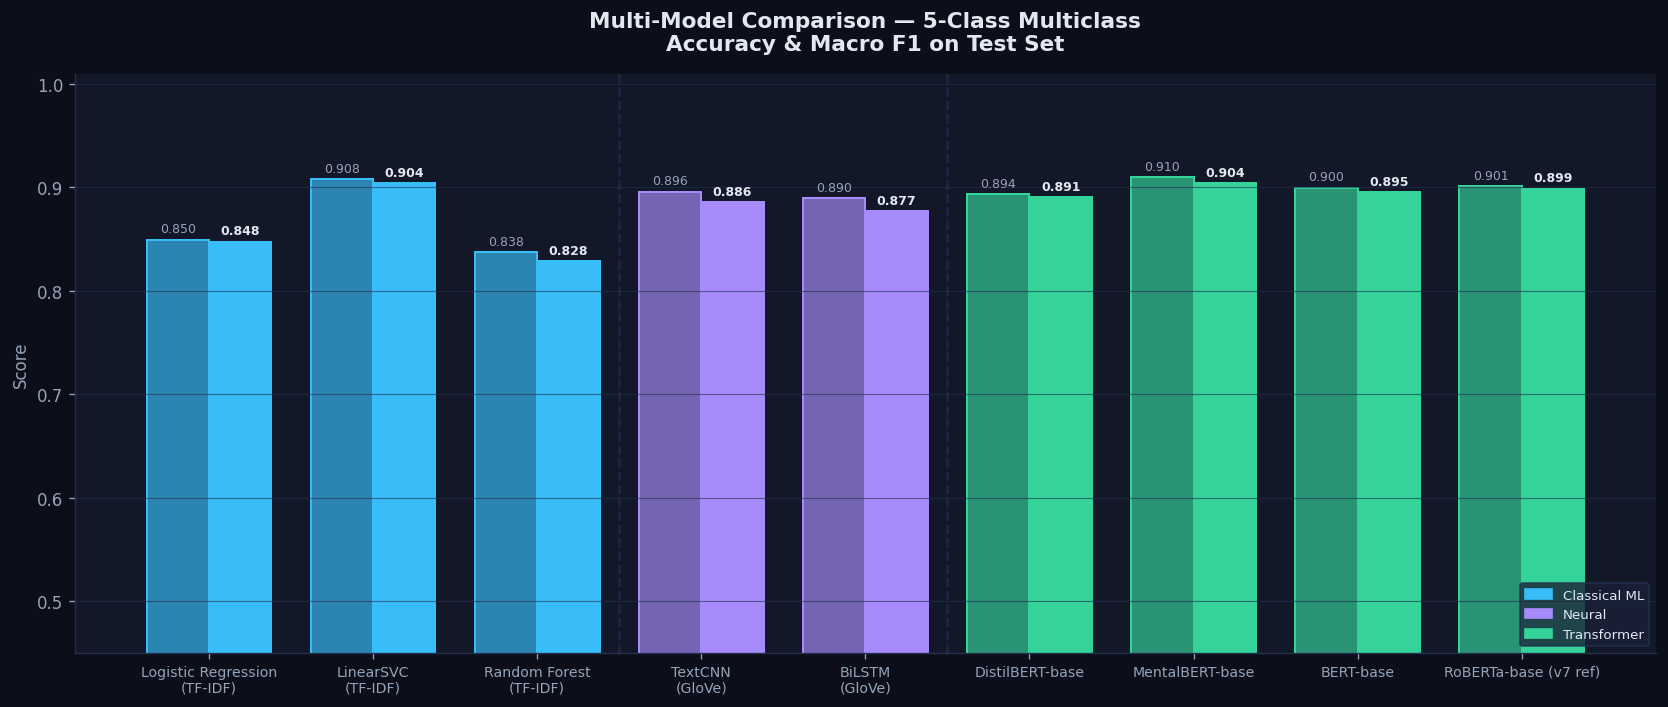

Saved: model_comparison_bar.png


In [41]:
PLOT_ORDER = [
    'Logistic Regression (TF-IDF)', 'LinearSVC (TF-IDF)', 'Random Forest (TF-IDF)',
    'TextCNN (GloVe-100d)', 'BiLSTM (GloVe-100d)',
    'DistilBERT-base', 'MentalBERT-base', 'BERT-base', 'RoBERTa-base (v7 ref)',
]
COLOR_MAP = {'Classical ML': '#38bdf8', 'Neural': '#a78bfa', 'Transformer': '#34d399'}
labels_plot, acc_vals, f1_vals, colors_plot = [], [], [], []
for name in PLOT_ORDER:
    if name in all_results:
        r = all_results[name]
        labels_plot.append(name); acc_vals.append(r['accuracy'])
        f1_vals.append(r['macro_f1']); colors_plot.append(COLOR_MAP.get(r['type'], '#94a3b8'))

x, width = np.arange(len(labels_plot)), 0.38
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0c0f1a'); ax.set_facecolor('#131828')
bars_acc = ax.bar(x - width/2, acc_vals, width, color=[c + 'aa' for c in colors_plot], edgecolor=colors_plot, linewidth=1.2)
bars_f1  = ax.bar(x + width/2, f1_vals,  width, color=colors_plot, edgecolor=colors_plot, linewidth=1.2)
for bar in bars_acc:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, color='#94a3b8')
for bar in bars_f1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, color='#e2e8f0', fontweight='bold')
ax.axvline(x=2.5, color='#243050', linewidth=1.5, linestyle='--', alpha=0.7)
ax.axvline(x=4.5, color='#243050', linewidth=1.5, linestyle='--', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([l.replace(' (TF-IDF)','\n(TF-IDF)').replace(' (GloVe-100d)','\n(GloVe)') for l in labels_plot], fontsize=8.5, color='#e2e8f0')
ax.set_ylim(0.45, 1.01); ax.set_ylabel('Score', color='#94a3b8', fontsize=10)
ax.set_title('Multi-Model Comparison — 5-Class Multiclass\nAccuracy & Macro F1 on Test Set', color='#e2e8f0', fontsize=13, fontweight='bold', pad=14)
ax.tick_params(colors='#94a3b8'); ax.spines['bottom'].set_color('#243050'); ax.spines['left'].set_color('#243050')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.yaxis.set_tick_params(labelcolor='#94a3b8'); ax.grid(axis='y', color='#243050', linewidth=0.7, alpha=0.6)
ax.legend(handles=[mpatches.Patch(color=c, label=t) for t, c in COLOR_MAP.items()],
          loc='lower right', fontsize=8, facecolor='#1a2238', edgecolor='#243050', labelcolor='#e2e8f0')
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight', facecolor='#0c0f1a')
plt.show()
print('Saved: model_comparison_bar.png')

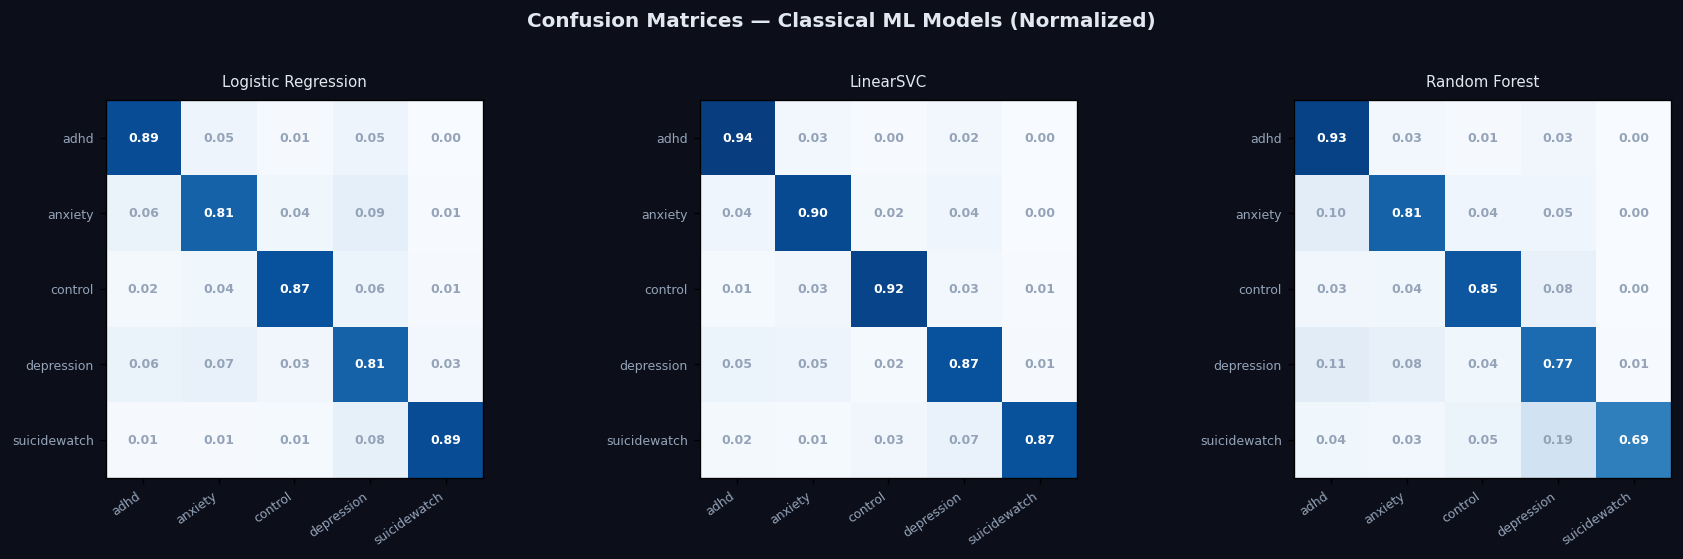

Saved: confusion_matrices_classical.png


In [42]:
def plot_confusion_matrix(cm, class_names, title, ax):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title, color='#e2e8f0', fontsize=9, pad=8)
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=35, ha='right', fontsize=7.5, color='#94a3b8')
    ax.set_yticklabels(class_names, fontsize=7.5, color='#94a3b8')
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            val = cm_norm[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=7.5, color='white' if val > 0.55 else '#94a3b8', fontweight='bold')
    ax.set_facecolor('#131828')

cl_models = [('Logistic Regression', lr_model.predict(X_test_tfidf)),
             ('LinearSVC',           svc_model.predict(X_test_tfidf)),
             ('Random Forest',       rf_model.predict(X_test_tfidf))]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.patch.set_facecolor('#0c0f1a')
fig.suptitle('Confusion Matrices — Classical ML Models (Normalized)', color='#e2e8f0', fontsize=12, fontweight='bold', y=1.02)
for ax, (title, preds) in zip(axes, cl_models):
    ax.set_facecolor('#131828')
    plot_confusion_matrix(confusion_matrix(test_df['_y'], preds), class_names, title, ax)
plt.tight_layout()
plt.savefig('confusion_matrices_classical.png', dpi=150, bbox_inches='tight', facecolor='#0c0f1a')
plt.show()
print('Saved: confusion_matrices_classical.png')

## Section 9 — Export Results to CSV

In [43]:
rows = []
for name, expected_type in ORDER:
    if name in all_results:
        r = all_results[name]
        rows.append({
            'model': name, 'tier': r['type'],
            'accuracy': round(r['accuracy'], 4), 'macro_f1': round(r['macro_f1'], 4),
            'weighted_f1': round(r['weighted_f1'], 4),
            'train_time_min': round(r['train_time_min'], 2) if r.get('train_time_min') is not None else None,
        })
results_df = pd.DataFrame(rows)
results_df.to_csv('model_comparison_results.csv', index=False)
print('Saved: model_comparison_results.csv')
print()
print(results_df.to_string(index=False))

Saved: model_comparison_results.csv

                       model         tier  accuracy  macro_f1  weighted_f1  train_time_min
Logistic Regression (TF-IDF) Classical ML    0.8496    0.8477       0.8500            0.26
          LinearSVC (TF-IDF) Classical ML    0.9080    0.9038       0.9080            0.07
      Random Forest (TF-IDF) Classical ML    0.8377    0.8284       0.8369            2.76
        TextCNN (GloVe-100d)       Neural    0.8959    0.8860       0.8959            0.92
         BiLSTM (GloVe-100d)       Neural    0.8900    0.8769       0.8907            9.05
             DistilBERT-base  Transformer    0.8939    0.8908       0.8941           42.03
             MentalBERT-base  Transformer    0.9103    0.9039       0.9108           81.20
                   BERT-base  Transformer    0.8998    0.8954       0.9007           81.25
       RoBERTa-base (v7 ref)  Transformer    0.9012    0.8988       0.9002             NaN


## Section 10 — Sample Inference Tests

Same 8 sample texts as v7. Each text is run through **all model types** so predictions can be
compared side-by-side across Classical ML, Neural (GloVe), and Transformer tiers.

| # | Text | Expected class |
|---|------|---------------|
| 1 | Overwhelmed, can't sleep, everything feels pointless... | depression? |
| 2 | I've been feeling really overwhelmed lately. | ambiguous |
| 3 | I feel so empty inside. I don't know what to do anymore. | depression |
| 4 | I don't know want to live anymore. | suicidewatch |
| 5 | I'm fine. Life seems okay... just a bit stressed with work. | control |
| 6 | Can't focus on anything lately, my brain is just not working. | adhd |
| 7 | Always worried, can't stop overthinking. | anxiety |
| 8 | Lost passion, don't enjoy anything anymore. | depression |

In [56]:
# ── Sample texts (same as v7) ───────────────────────────────────────────────
SAMPLE_TESTS = [
    ("I've been feeling really overwhelmed lately, can't sleep, and everything feels pointless. I don't know what to do anymore.", "depression?"),
    ("I've been feeling really overwhelmed lately.", "ambiguous"),
    ("I feel so empty inside. I don't know what to do anymore.", "depression"),
    ("I don't know want to live anymore.", "suicidewatch"),
    ("I'm fine.life seems okay.everything is good.just a bit stressed with work. so i'm a little worried about that.", "control"),
    ("i can't foucs on anything latly , it's like my brain is just not working.i can't even read a book without losing focus after a few sentences.", "adhd"),
    ("my brain is not letting me relax , i'm always worried about something    though i know can't fix everything but i can't stop overthinking", "anxiety"),
    ("i'm feeling like i've lost passion on everything, i don't enjoy anything anymore                 it does not make a difference for me if it is a small or big thing, i just don't care anymore.", "depression"),
]


# ── Classical ML predictor ────────────────────────────────────────────────────
def predict_classical(text, model, vectorizer, class_names):
    clean = minimal_preprocess(text)
    vec   = vectorizer.transform([clean])
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(vec)[0]
    else:  # LinearSVC — stable softmax over decision scores
        scores = model.decision_function(vec)[0]
        scores = scores - scores.max()
        probs  = np.exp(scores) / np.exp(scores).sum()
    return class_names[int(probs.argmax())], probs


# ── Neural (TextCNN / BiLSTM) predictor ─────────────────────────────────────────
def predict_neural(text, model, word2idx, max_len, class_names, device):
    clean  = minimal_preprocess(text)
    tokens = clean.split()[:max_len]
    seq    = [word2idx.get(t, 1) for t in tokens] + [0] * (max_len - len(tokens))
    x      = torch.tensor([seq], dtype=torch.long).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1).cpu().numpy()[0]
    return class_names[int(probs.argmax())], probs


# ── Generic transformer predictor ─────────────────────────────────────────────
def predict_transformer(text, hf_model_name, checkpoint_path,
                        num_labels, class_names, device, max_length=256, fallbacks=None):
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    
    tokenizer = None
    used_model_name = hf_model_name
    try:
        tokenizer = AutoTokenizer.from_pretrained(hf_model_name)
    except Exception as e:
        print(f"Warning: Failed to load tokenizer for '{hf_model_name}'. Error: {e}")
        if fallbacks:
            for fb in fallbacks:
                try:
                    print(f"Trying to load fallback tokenizer from local cache: {fb}...")
                    tokenizer = AutoTokenizer.from_pretrained(fb, local_files_only=True)
                    print(f"Successfully loaded fallback tokenizer: {fb}")
                    used_model_name = fb
                    break
                except Exception as fb_err:
                    print(f"Failed to load fallback tokenizer '{fb}': {fb_err}")
        if tokenizer is None:
            raise e

    mdl = None
    try:
        mdl = AutoModelForSequenceClassification.from_pretrained(
            used_model_name, num_labels=num_labels,
            id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True,
            local_files_only=(used_model_name != hf_model_name)
        ).to(device)
    except Exception as e:
        print(f"Warning: Failed to load model '{used_model_name}'. Error: {e}")
        if fallbacks and used_model_name == hf_model_name:
            for fb in fallbacks:
                try:
                    print(f"Trying to load fallback model from local cache: {fb}...")
                    mdl = AutoModelForSequenceClassification.from_pretrained(
                        fb, num_labels=num_labels,
                        id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True,
                        local_files_only=True
                    ).to(device)
                    print(f"Successfully loaded fallback model: {fb}")
                    break
                except Exception as fb_err:
                    print(f"Failed to load fallback model '{fb}': {fb_err}")
        if mdl is None:
            raise e

    mdl.load_state_dict(torch.load(checkpoint_path, map_location=device))
    mdl.eval()
    clean = minimal_preprocess(text)
    enc   = tokenizer(clean, max_length=max_length, padding='max_length',
                      truncation=True, return_tensors='pt')
    enc   = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        probs = torch.softmax(mdl(**enc).logits, dim=1).cpu().numpy()[0]
    del mdl
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return class_names[int(probs.argmax())], probs


# ── RoBERTa v7 predictor ──────────────────────────────────────────────────────
def predict_roberta_v7(text, checkpoint_path, num_labels, class_names, device, max_length=256):
    from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
    id2label = {i: n for i, n in enumerate(class_names)}
    label2id = {n: i for i, n in enumerate(class_names)}
    tok = RobertaTokenizerFast.from_pretrained('roberta-base')
    mdl = RobertaForSequenceClassification.from_pretrained(
        'roberta-base', num_labels=num_labels,
        id2label=id2label, label2id=label2id,
    ).to(device)
    mdl.load_state_dict(torch.load(checkpoint_path, map_location=device))
    mdl.eval()
    clean = minimal_preprocess(text)
    enc = tok(clean, max_length=max_length, padding='max_length',
              truncation=True, return_tensors='pt')
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        probs = torch.softmax(mdl(**enc).logits, dim=1).cpu().numpy()[0]
    del mdl
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return class_names[int(probs.argmax())], probs


print('Inference helpers defined.')

Inference helpers defined.


In [57]:
# ── Load saved neural checkpoints for inference ───────────────────────────────
textcnn_inf = TextCNN(
    vocab_size=vocab_size, embed_dim=EMBED_DIM, num_classes=num_labels,
    num_filters=128, filter_sizes=(3, 4, 5), dropout=0.5,
)
textcnn_inf.load_state_dict(torch.load('best_textcnn_multiclass_v1.pt', map_location=device))
textcnn_inf = textcnn_inf.to(device)

bilstm_inf = BiLSTMClassifier(
    vocab_size=vocab_size, embed_dim=EMBED_DIM, hidden_dim=256,
    num_classes=num_labels, num_layers=2, dropout=0.3,
)
bilstm_inf.load_state_dict(torch.load('best_bilstm_multiclass_v1.pt', map_location=device))
bilstm_inf = bilstm_inf.to(device)
print('Neural checkpoints loaded.\n')

# ── Classical & Neural — compact table ────────────────────────────────────────
CL_NN_MODELS = [
    ('LR',        lambda t: predict_classical(t, lr_model,  tfidf, class_names)),
    ('LinearSVC', lambda t: predict_classical(t, svc_model, tfidf, class_names)),
    ('RF',        lambda t: predict_classical(t, rf_model,  tfidf, class_names)),
    ('TextCNN',   lambda t: predict_neural(t, textcnn_inf, word2idx, MAX_LEN_NEURAL, class_names, device)),
    ('BiLSTM',    lambda t: predict_neural(t, bilstm_inf,  word2idx, MAX_LEN_NEURAL, class_names, device)),
]

W = 16
SEP = '=' * (55 + W * len(CL_NN_MODELS))
print(SEP)
print('SAMPLE INFERENCE — Classical ML & Neural Models')
print(SEP)
print(f'{"#":<3} {"Text (truncated)":<42} {"Expected":<10}' + ''.join(f'{n:<{W}}' for n, _ in CL_NN_MODELS))
print('-' * (55 + W * len(CL_NN_MODELS)))
for i, (text, expected) in enumerate(SAMPLE_TESTS):
    short = (text[:39] + '...') if len(text) > 39 else text
    row = f'{i+1:<3} {short:<42} {expected:<10}'
    for name, fn in CL_NN_MODELS:
        pred, probs = fn(text)
        row += f'{pred:<10}({probs.max():.2f})  '
    print(row)
print(SEP)

Neural checkpoints loaded.

SAMPLE INFERENCE — Classical ML & Neural Models
#   Text (truncated)                           Expected  LR              LinearSVC       RF              TextCNN         BiLSTM          
---------------------------------------------------------------------------------------------------------------------------------------
1   I've been feeling really overwhelmed la... depression?depression(0.67)  depression(0.55)  depression(0.42)  depression(0.77)  depression(0.97)  
2   I've been feeling really overwhelmed la... ambiguous depression(0.61)  depression(0.53)  depression(0.54)  depression(0.58)  depression(0.38)  
3   I feel so empty inside. I don't know wh... depressionsuicidewatch(0.53)  suicidewatch(0.31)  depression(0.56)  suicidewatch(0.89)  suicidewatch(0.90)  
4   I don't know want to live anymore.         suicidewatchsuicidewatch(0.98)  suicidewatch(0.83)  suicidewatch(0.59)  suicidewatch(1.00)  suicidewatch(0.99)  
5   I'm fine. life seems okay. everyt

In [58]:
# ── Transformer models sample inference ───────────────────────────────────────
TRANSFORMER_MODELS = [
    ('DistilBERT', 'distilbert-base-uncased',        'best_distilbert_multiclass_v1.pt'),
    ('MentalBERT', 'mental/mental-bert-base-uncased', 'best_mentalbert_multiclass_v1.pt'),
    ('BERT-base',  'bert-base-uncased',               'best_bert_multiclass_v1.pt'),
    ('RoBERTa-v7', None,                              'best_roberta_multiclass_v7.pt'),
]

# results_inf[model_name][sample_idx] = (pred_label, conf, probs)
results_inf = {name: [] for name, _, _ in TRANSFORMER_MODELS}

for display_name, hf_name, ckpt in TRANSFORMER_MODELS:
    print(f'Loading {display_name} from {ckpt}...')
    for text, _ in SAMPLE_TESTS:
        if display_name == 'RoBERTa-v7':
            pred, probs = predict_roberta_v7(text, ckpt, num_labels, class_names, device)
        else:
            fallbacks = None
            if display_name == 'MentalBERT':
                fallbacks = ['slimshady07/Mental_BERT', 'Sharath45/MENTALBERT_MULTILABEL_CLASSIFICATION']
            pred, probs = predict_transformer(text, hf_name, ckpt, num_labels, class_names, device, fallbacks=fallbacks)
        results_inf[display_name].append((pred, float(probs.max()), probs))
    print(f'  Done ({len(SAMPLE_TESTS)} samples).\n')

W2 = 18
SEP2 = '=' * (55 + W2 * len(TRANSFORMER_MODELS))
print(SEP2)
print('SAMPLE INFERENCE — Transformer Models')
print(SEP2)
print(f'{"#":<3} {"Text (truncated)":<42} {"Expected":<10}' + ''.join(f'{n:<{W2}}' for n, _, _ in TRANSFORMER_MODELS))
print('-' * (55 + W2 * len(TRANSFORMER_MODELS)))
for i, (text, expected) in enumerate(SAMPLE_TESTS):
    short = (text[:39] + '...') if len(text) > 39 else text
    row = f'{i+1:<3} {short:<42} {expected:<10}'
    for name, _, _ in TRANSFORMER_MODELS:
        pred, conf, _ = results_inf[name][i]
        row += f'{pred:<11}({conf:.2f})   '
    print(row)
print(SEP2)

Loading DistilBERT from best_distilbert_multiclass_v1.pt...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-strea

  Done (8 samples).

Loading MentalBERT from best_mentalbert_multiclass_v1.pt...
Make sure to have access to it at https://huggingface.co/mental/mental-bert-base-uncased.
403 Client Error. (Request ID: Root=1-6a3e83d9-04c1b0e71b16195f0491e95b;24e49e34-65e4-4a44-b17d-fbe505fcb6de)

Cannot access gated repo for url https://huggingface.co/mental/mental-bert-base-uncased/resolve/main/config.json.
Access to model mental/mental-bert-base-uncased is restricted and you are not in the authorized list. Visit https://huggingface.co/mental/mental-bert-base-uncased to ask for access.
Trying to load fallback tokenizer from local cache: slimshady07/Mental_BERT...
Successfully loaded fallback tokenizer: slimshady07/Mental_BERT


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at slimshady07/Mental_BERT and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([2]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([2, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Make sure to have access to it at https://huggingface.co/mental/mental-bert-base-uncased.
403 Client Error. (Request ID: Root=1-6a3e83dd-738bc46f738b13685db16722;7d7d43c3-8d45-41c6-b497-59139d958e68)

Cannot access gated repo for url https://huggingface.co/mental/mental-bert-base-uncased/resolve/main/config.json.
Access to model mental/mental-bert-base-uncased is restricted and you are not in the authorized list. Visit https://huggingface.co/mental/mental-bert-base-uncased to ask for access.
Trying to load fallback tokenizer from local cache: slimshady07/Mental_BERT...
Successfully loaded fallback tokenizer: slimshady07/Mental_BERT


...

  Done (8 samples).

Loading BERT-base from best_bert_multiclass_v1.pt...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are

  Done (8 samples).

Loading RoBERTa-v7 from best_roberta_multiclass_v7.pt...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN th

  Done (8 samples).

SAMPLE INFERENCE — Transformer Models
#   Text (truncated)                           Expected  DistilBERT        MentalBERT        BERT-base         RoBERTa-v7        
-------------------------------------------------------------------------------------------------------------------------------
1   I've been feeling really overwhelmed la... depression?anxiety    (0.98)   depression (0.89)   control    (0.89)   control    (0.97)   
2   I've been feeling really overwhelmed la... ambiguous control    (1.00)   adhd       (0.99)   control    (1.00)   adhd       (0.58)   
3   I feel so empty inside. I don't know wh... depressioncontrol    (0.48)   depression (0.95)   control    (0.56)   depression (0.61)   
4   I don't know want to live anymore.         suicidewatchsuicidewatch(0.97)   suicidewatch(1.00)   suicidewatch(1.00)   suicidewatch(1.00)   
5   I'm fine. life seems okay. everything i... control   control    (1.00)   control    (1.00)   control    (1.00)   control

In [59]:
# ── Detailed per-sample breakdown with top-3 probabilities per model ──────────
# Matches v7's predict_single() output style, extended to all 8 models.

def fmt_top3(probs, class_names, n=3):
    top = np.argsort(probs)[::-1][:n]
    return '  '.join(f'{class_names[j]}={probs[j]:.3f}' for j in top)


print('\n' + '='*100)
print('DETAILED PER-SAMPLE BREAKDOWN  (top-3 probabilities per model)')
print('='*100)

for i, (text, expected) in enumerate(SAMPLE_TESTS):
    short_text = text[:120] + ('...' if len(text) > 120 else '')
    print(f'\n{"-"*100}')
    print(f'Sample {i+1} | Expected: {expected}')
    print(f'Input: "{short_text}"')
    print(f'{"-"*100}')

    # Classical ML
    for mname, clf, label in [
        ('Logistic Regression', lr_model,  'Classical ML'),
        ('LinearSVC',           svc_model, 'Classical ML'),
        ('Random Forest',       rf_model,  'Classical ML'),
    ]:
        pred, probs = predict_classical(text, clf, tfidf, class_names)
        marker = ' ✓' if pred == expected else ''
        print(f'  {mname:<24} → {pred:<14}{marker}  [{fmt_top3(probs, class_names)}]')

    # Neural
    pred, probs = predict_neural(text, textcnn_inf, word2idx, MAX_LEN_NEURAL, class_names, device)
    marker = ' ✓' if pred == expected else ''
    print(f'  {"TextCNN (GloVe)":<24} → {pred:<14}{marker}  [{fmt_top3(probs, class_names)}]')

    pred, probs = predict_neural(text, bilstm_inf, word2idx, MAX_LEN_NEURAL, class_names, device)
    marker = ' ✓' if pred == expected else ''
    print(f'  {"BiLSTM (GloVe)":<24} → {pred:<14}{marker}  [{fmt_top3(probs, class_names)}]')

    # Transformers (already cached in results_inf)
    for tname, _, _ in TRANSFORMER_MODELS:
        pred, conf, probs = results_inf[tname][i]
        marker = ' ✓' if pred == expected else ''
        print(f'  {tname:<24} → {pred:<14}{marker}  [{fmt_top3(probs, class_names)}]')

print('\n' + '='*100)


DETAILED PER-SAMPLE BREAKDOWN  (top-3 probabilities per model)

----------------------------------------------------------------------------------------------------
Sample 1 | Expected: depression?
Input: "I've been feeling really overwhelmed lately, can't sleep, and everything feels pointless. I don't know what to do anymor..."
----------------------------------------------------------------------------------------------------
  Logistic Regression      → depression      [depression=0.666  suicidewatch=0.169  anxiety=0.090]
  LinearSVC                → depression      [depression=0.551  suicidewatch=0.159  anxiety=0.137]
  Random Forest            → depression      [depression=0.420  suicidewatch=0.210  adhd=0.182]
  TextCNN (GloVe)          → depression      [depression=0.775  anxiety=0.146  suicidewatch=0.070]
  BiLSTM (GloVe)           → depression      [depression=0.966  suicidewatch=0.022  anxiety=0.006]
  DistilBERT               → anxiety         [anxiety=0.980  depression=0.0

## Section 11 — RoBERTa Evolution (v2 to v7)

Here we compare the performance of RoBERTa-base across 6 iterative fine-tuning experiments, showcasing the effect of dataset curation, balancing, and control-data augmentation.

| Version | Description | Train Size | Accuracy | Macro F1 | Weighted F1 |
|---|---|---|---|---|---|
| **v2** | Augmented to include various length samples | 98,288 | 0.8997 | 0.8756 | 0.9030 |
| **v3** | Generated samples for control class | 71,144 | 0.9205 | 0.9092 | 0.9213 |
| **v4 (★ Best)** | Filtered to include only direct suicidal confessions | 57,095 | 0.9344 | **0.9240** | 0.9349 |
| **v5** | Control class emotional confessions, suicide watch restored | 44,534 | 0.8633 | 0.8593 | 0.8652 |
| **v6** | Included optimistic examples, suicide watch restored | 44,584 | 0.8905 | 0.8862 | 0.8914 |
| **v7** | Same as CAST dataset but filtered suicide watch again | 35,040 | 0.9012 | 0.8988 | 0.9002 |

> **Insight:** v4 achieved the highest overall Macro F1 (0.9240) despite having fewer training samples than v2 and v3. This highlights the importance of data quality over pure volume, specifically the inclusion of enriched self-report control posts.


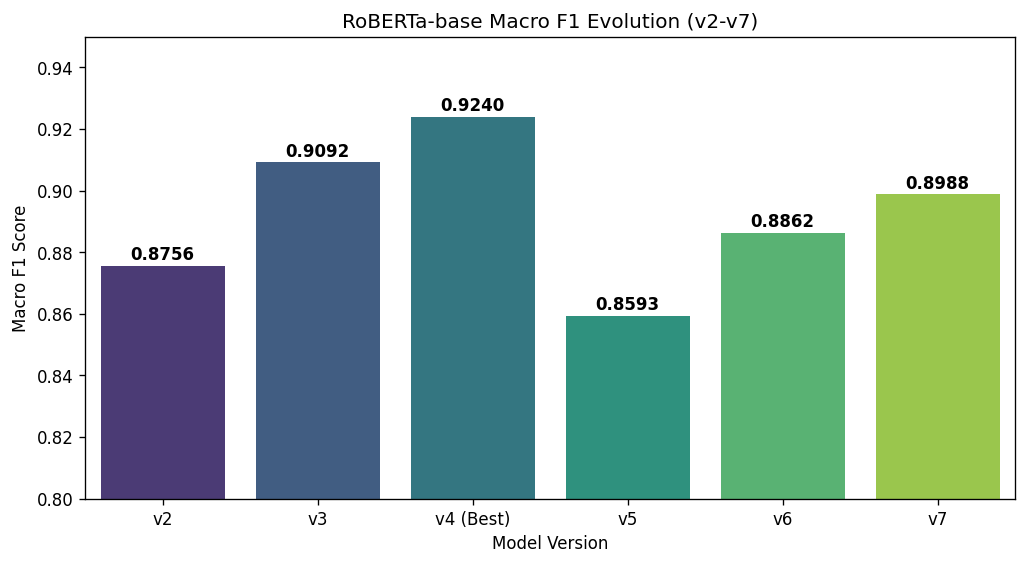

In [52]:
# Visualize RoBERTa Evolution (Macro F1)
import matplotlib.pyplot as plt
import seaborn as sns

versions = ['v2', 'v3', 'v4 (Best)', 'v5', 'v6', 'v7']
f1_scores = [0.8756, 0.9092, 0.9240, 0.8593, 0.8862, 0.8988]

plt.figure(figsize=(10, 5))
sns.barplot(x=versions, y=f1_scores, palette='viridis')
plt.ylim(0.80, 0.95)
plt.title('RoBERTa-base Macro F1 Evolution (v2-v7)')
plt.ylabel('Macro F1 Score')
plt.xlabel('Model Version')
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()
